First 5 Rows of Dataset:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8

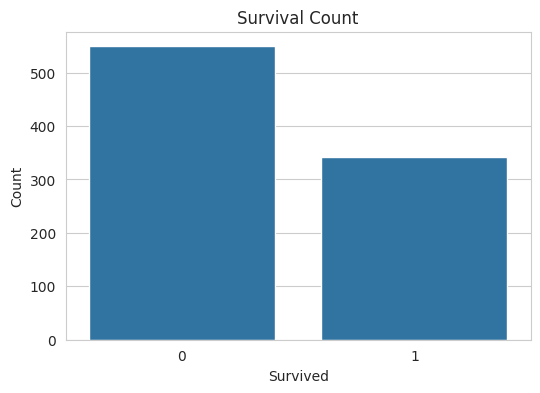

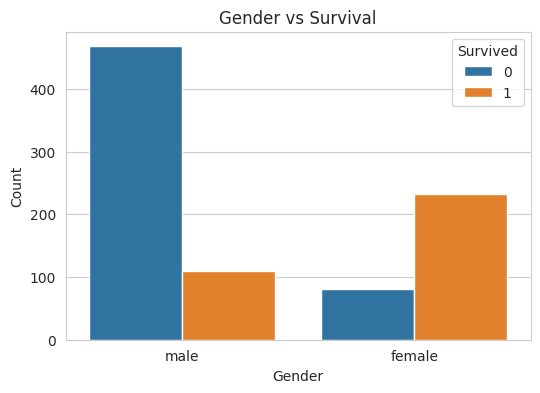

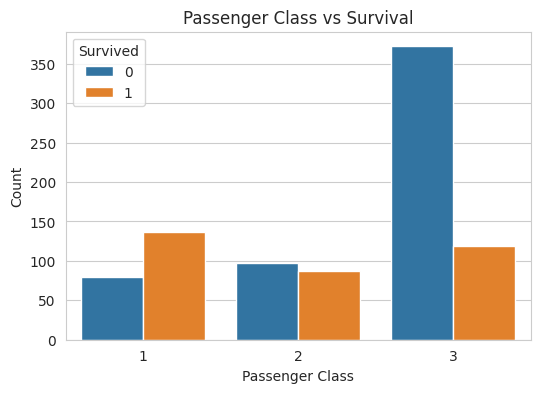

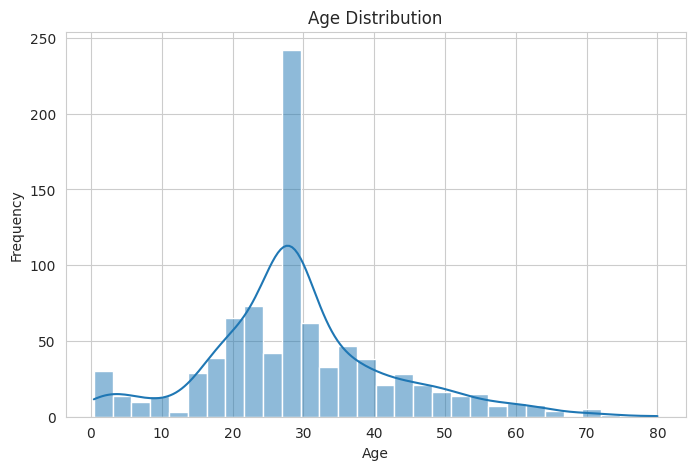

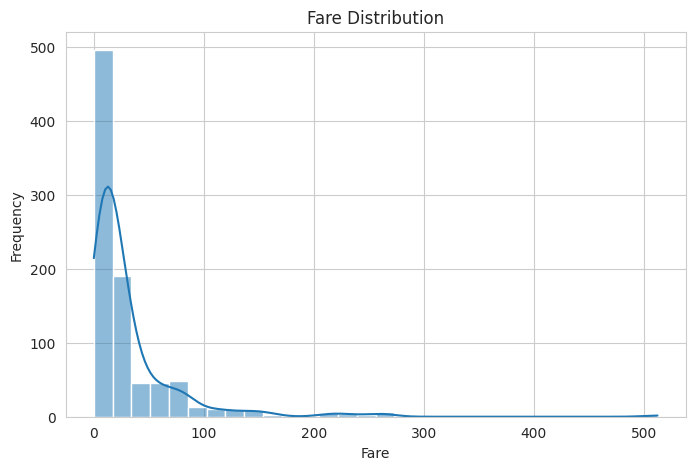

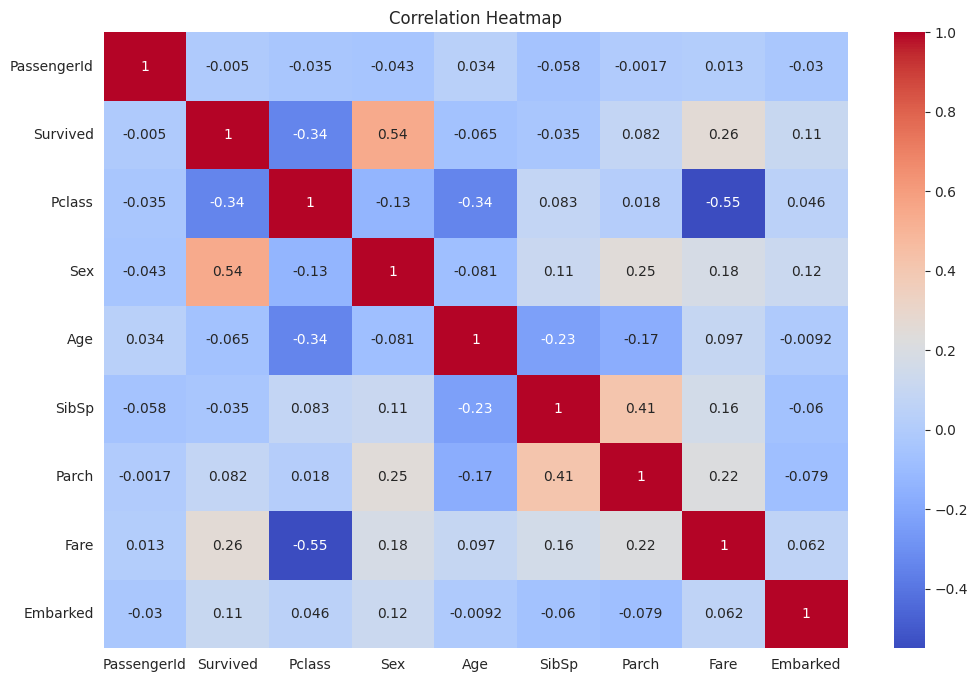


Survival Rate by Gender:
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

Survival Rate by Passenger Class:
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

================ INSIGHTS ================

1. Female passengers had a higher survival rate compared to males.
2. First-class passengers survived more than second and third class passengers.
3. Passenger fare had a positive relationship with survival.
4. Most passengers were between 20 and 40 years old.
5. Data visualization helped identify patterns and correlations effectively.



In [1]:
# ============================================
# Exploratory Data Analysis on Titanic Dataset
# ============================================

# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Set Visualization Style
sns.set_style('whitegrid')

# ============================================
# Load Dataset from Internet
# ============================================

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)

# ============================================
# Display First 5 Rows
# ============================================

print("First 5 Rows of Dataset:")
print(df.head())

# ============================================
# Dataset Information
# ============================================

print("\nShape of Dataset:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
print(df.info())

# ============================================
# Missing Values
# ============================================

print("\nMissing Values:")
print(df.isnull().sum())

# ============================================
# Statistical Summary
# ============================================

print("\nStatistical Summary:")
print(df.describe())

# ============================================
# Data Cleaning
# ============================================

# Fill missing Age values with median
df['Age'].fillna(df['Age'].median(), inplace=True)

# Fill missing Embarked values with mode
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Drop Cabin column due to excessive missing values
df.drop('Cabin', axis=1, inplace=True)

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

# ============================================
# Survival Count Visualization
# ============================================

plt.figure(figsize=(6,4))
sns.countplot(x='Survived', data=df)

plt.title('Survival Count')
plt.xlabel('Survived')
plt.ylabel('Count')

plt.show()

# ============================================
# Gender vs Survival
# ============================================

plt.figure(figsize=(6,4))
sns.countplot(x='Sex', hue='Survived', data=df)

plt.title('Gender vs Survival')
plt.xlabel('Gender')
plt.ylabel('Count')

plt.show()

# ============================================
# Passenger Class vs Survival
# ============================================

plt.figure(figsize=(6,4))
sns.countplot(x='Pclass', hue='Survived', data=df)

plt.title('Passenger Class vs Survival')
plt.xlabel('Passenger Class')
plt.ylabel('Count')

plt.show()

# ============================================
# Age Distribution
# ============================================

plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=30, kde=True)

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()

# ============================================
# Fare Distribution
# ============================================

plt.figure(figsize=(8,5))
sns.histplot(df['Fare'], bins=30, kde=True)

plt.title('Fare Distribution')
plt.xlabel('Fare')
plt.ylabel('Frequency')

plt.show()

# ============================================
# Correlation Heatmap
# ============================================

# Convert categorical variables for correlation
encoded_df = df.copy()

encoded_df['Sex'] = encoded_df['Sex'].map({'male':0, 'female':1})
encoded_df['Embarked'] = encoded_df['Embarked'].map({'S':0, 'C':1, 'Q':2})

numeric_df = encoded_df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.show()

# ============================================
# Survival Rate by Gender
# ============================================

survival_gender = df.groupby('Sex')['Survived'].mean()

print("\nSurvival Rate by Gender:")
print(survival_gender)

# ============================================
# Survival Rate by Passenger Class
# ============================================

survival_class = df.groupby('Pclass')['Survived'].mean()

print("\nSurvival Rate by Passenger Class:")
print(survival_class)

# ============================================
# Key Insights
# ============================================

print("\n================ INSIGHTS ================\n")

print("1. Female passengers had a higher survival rate compared to males.")
print("2. First-class passengers survived more than second and third class passengers.")
print("3. Passenger fare had a positive relationship with survival.")
print("4. Most passengers were between 20 and 40 years old.")
print("5. Data visualization helped identify patterns and correlations effectively.")

print("\n==========================================")

# ============================================
# End of Project
# ============================================